In [1]:
import networkx as nx
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.cm as cmx
import matplotlib.colors as colors

from sklearn import metrics
import matplotlib.pyplot as plt
import copy
import scipy.sparse as sp
import scanpy as sc
import os
import anndata as ad
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
gene_TCR = ad.read_h5ad('./10Xdatasets/gex_merge_log1_5000_genes_all_peptides.h5ad')
gene_TCR.obs['used_ix'] = range(gene_TCR.shape[0])
donor_4 = gene_TCR[gene_TCR.obs.donor == 'donor4']
donor_4

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 21393 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', '

In [3]:
data_10X_dat = donor_4.obs
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
TTGGAACTCCGTCATC-8,TRAV12-2,TRBV5-1,None,TRBD2,TRAJ50,TRBJ2-7,TRAC,TRBC2,CAVETSYDKVIF,CASSTGAGEQYF,...,0.0,0.0,unknown,nan,134651,4739.0,3.675687,1286,0.048322,124086
GACGTTAAGATGTCGG-8,TRAV17,TRBV5-4,None,TRBD1,TRAJ23,TRBJ2-1,TRAC,TRBC2,CAPRDYNQGGKLIF,CASSLRGANNEQFF,...,0.0,0.0,unknown,nan,134652,5541.0,3.743588,1500,0.058654,124087
CGTGTAAAGGGCACTA-6,TRAV8-3,TRBV30,None,None,TRAJ27,TRBJ1-2,TRAC,TRBC1,CAVGDTNAGKSTF,CAWRGFRGYTF,...,0.0,0.0,unknown,nan,134654,6566.0,3.817301,1835,0.040207,124088
ATCCGAAGTTTGGGCC-2,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,134655,4231.0,3.626443,1575,0.039471,124089
CTCGAAAAGGAGTAGA-3,TRAV1-2,TRBV5-4,None,TRBD1,TRAJ20,TRBJ2-5,TRAC,TRBC2,CAVLNDYKLSF,CASSLWTGPQETQYF,...,0.0,0.0,unknown,nan,134656,5504.0,3.740678,1645,0.035610,124090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [4]:
from sklearn.decomposition import NMF

In [5]:
# model_nmf = NMF(n_components=100, init='random', random_state=0)
# model_nmf.fit(donor_4.X)

In [6]:
# W = model_nmf.transform(donor_4.X)
# H = model_nmf.components_

In [7]:
# W_df = pd.DataFrame(W)

In [8]:
# W_df

In [9]:
# all_embeddings_df = pd.read_csv('./data_10X_full_data_emb_dat_mvTCR_clean_PCAs_041.csv')
all_embeddings_df_alpha_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_alpha_chain_10X_donor_4_only.csv')
all_embeddings_df_beta_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_beta_chain_10X_donor_4_only_022626.csv')


In [10]:
all_embeddings_df_beta_chain

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0000,44.936493,91.680640,0.0,0.0,0.0,53.601440,38.394030,0.0,...,0.0,0.000000,0.0,27.987392,122.077484,0.0,0.0,0.00000,0.000000,0.000000
1,0.000000,0.0000,122.068420,144.880680,0.0,0.0,0.0,235.171190,133.973590,0.0,...,0.0,0.000000,0.0,0.000000,58.173520,0.0,0.0,0.00000,0.000000,92.982040
2,0.000000,0.0000,177.388380,175.409530,0.0,0.0,0.0,264.593540,50.165634,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,50.614620
3,0.000000,0.0000,79.017914,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,55.561527,0.0,97.908570,83.885185,0.0,0.0,35.34587,0.000000,0.000000
4,0.000000,0.0000,144.278120,73.185326,0.0,0.0,0.0,172.237820,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,97.810320,0.0,0.0,0.00000,0.000000,18.829268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21388,0.000000,0.0000,83.636475,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,108.500020,0.0,115.580770,166.173480,0.0,0.0,71.59820,0.000000,0.000000
21389,15.489287,0.0000,82.227960,85.610450,0.0,0.0,0.0,161.260820,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,218.587600,0.0,0.0,0.00000,0.000000,62.542667
21390,0.000000,208.6073,189.220610,269.774320,0.0,0.0,0.0,19.516222,100.878340,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.00000,55.067757,68.850570
21391,0.000000,0.0000,101.666340,159.804280,0.0,0.0,0.0,189.779170,125.373990,0.0,...,0.0,0.000000,0.0,0.000000,56.488537,0.0,0.0,0.00000,0.000000,0.000000


In [11]:

# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain, W_df], axis=1)
# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain], axis=1)
all_embed = all_embeddings_df_beta_chain
all_embed

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0000,44.936493,91.680640,0.0,0.0,0.0,53.601440,38.394030,0.0,...,0.0,0.000000,0.0,27.987392,122.077484,0.0,0.0,0.00000,0.000000,0.000000
1,0.000000,0.0000,122.068420,144.880680,0.0,0.0,0.0,235.171190,133.973590,0.0,...,0.0,0.000000,0.0,0.000000,58.173520,0.0,0.0,0.00000,0.000000,92.982040
2,0.000000,0.0000,177.388380,175.409530,0.0,0.0,0.0,264.593540,50.165634,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,50.614620
3,0.000000,0.0000,79.017914,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,55.561527,0.0,97.908570,83.885185,0.0,0.0,35.34587,0.000000,0.000000
4,0.000000,0.0000,144.278120,73.185326,0.0,0.0,0.0,172.237820,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,97.810320,0.0,0.0,0.00000,0.000000,18.829268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21388,0.000000,0.0000,83.636475,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,108.500020,0.0,115.580770,166.173480,0.0,0.0,71.59820,0.000000,0.000000
21389,15.489287,0.0000,82.227960,85.610450,0.0,0.0,0.0,161.260820,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,218.587600,0.0,0.0,0.00000,0.000000,62.542667
21390,0.000000,208.6073,189.220610,269.774320,0.0,0.0,0.0,19.516222,100.878340,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.00000,55.067757,68.850570
21391,0.000000,0.0000,101.666340,159.804280,0.0,0.0,0.0,189.779170,125.373990,0.0,...,0.0,0.000000,0.0,0.000000,56.488537,0.0,0.0,0.00000,0.000000,0.000000


In [12]:
import anndata as ad

In [13]:
donor_1_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           
donor_2_peptides = ['B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder',          
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder']      
donor_3_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',           
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'B0801_RAKFKQLL_BZLF1_EBV_binder']            
donor_4_peptides = ['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',       
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           

In [14]:
top16_peptide = data_10X_dat.antigen.value_counts().index.to_list()
top16_peptide

['unknown',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A0201_YLLEMLWRL_LMP1_EBV_binder',
 'A0201_KLQCVDLHV_PSA146-154_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'A0201_NLVPMVATV_pp65_CMV_binder',
 'A0201_SLYNTVATLY_Gag-protein_HIV_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A2402_QYDPVAALF_pp65_CMV_binder',
 'B0801_ELRRKMMYM_IE-1_CMV_binder']

In [15]:
data_10X_dat.columns

Index(['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA',
       'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB',
       'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor',
       'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA',
       'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b',
       'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV',
       'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer',
       'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer',
       'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer',
       'A0201_KVLEYVIKV_MAGE-A1_Cancer',
       'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase',
       'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91',
       'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV',
       'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza',
       'A0201_GLCTLVAML_BML

In [16]:
top16_peptide[1:10]

['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder']

In [17]:
bind_list = top16_peptide[1:10]
bind_list.append('unknown')
bind_list

['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'unknown']

In [18]:
from distinctipy import distinctipy

colors_distinct = distinctipy.get_colors(len(bind_list)-1)


In [19]:
colors_distinct.append((0.75,0.75,0.75))
colors_distinct

[(0.0, 1.0, 0.0),
 (1.0, 0.0, 1.0),
 (0.0, 0.5, 1.0),
 (1.0, 0.5, 0.0),
 (0.5, 0.75, 0.5),
 (0.2991826502006746, 0.02171819024467936, 0.6440241817896073),
 (0.7945172077813402, 0.007117783663984856, 0.14817292131535265),
 (0.14599778478276093, 0.9985447529957189, 0.9707072971621269),
 (0.004917915137390483, 0.43177576140298135, 0.3227523018022316),
 (0.75, 0.75, 0.75)]

In [20]:
antigen_colors = dict(map(lambda i,j : (i,j) , bind_list,colors_distinct))
antigen_colors

{'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.0, 1.0, 0.0),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (1.0, 0.0, 1.0),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.0, 0.5, 1.0),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (1.0, 0.5, 0.0),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.5, 0.75, 0.5),
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder': (0.2991826502006746,
  0.02171819024467936,
  0.6440241817896073),
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder': (0.7945172077813402,
  0.007117783663984856,
  0.14817292131535265),
 'A0201_LLFGYPVYV_HTLV-1_binder': (0.14599778478276093,
  0.9985447529957189,
  0.9707072971621269),
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder': (0.004917915137390483,
  0.43177576140298135,
  0.3227523018022316),
 'unknown': (0.75, 0.75, 0.75)}

In [21]:
top16_peptide[1:10]

['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder']

In [45]:

from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_4
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_4_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([25, 30,35]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_gene, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_gene, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_gene.obs['leiden'].astype('int').values,
                adata_gene.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
  0%|          | 0/3 [00:00<?, ?it/s]

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3619384418380612, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.3718586161747049, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.3700592419396481, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.36260609355944573, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.3628495511764061, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.36467974725888497, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.35498474454803636, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.34398074640078846, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.3775959452865229, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.35933013386132967, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.31703304199905946, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.36269089257792386, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.3526530641044426, PCs: 25
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.

 33%|███▎      | 1/3 [00:41<01:23, 41.95s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.28694380117613655, PCs: 25
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3983033306667089, PCs: 30
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.3648106015039778, PCs: 30
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.3577814149578125, PCs: 30
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.34167178391789804, PCs: 30
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.36172661671705797, PCs: 30
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.34982134862720715, PCs: 30
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3595298509090638, PCs: 30
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3449835852791388, PCs: 30
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.39314803426823286, PCs: 30
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.35534526817199225, PCs: 30
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.37084154690734766, PCs: 30
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.3475698743837171, PCs: 30
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.

 67%|██████▋   | 2/3 [01:24<00:42, 42.31s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.3098119347833946, PCs: 30
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3579700489421923, PCs: 35
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.34487548120447975, PCs: 35
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.3652618431253855, PCs: 35
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.35135778662809325, PCs: 35
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.358339195870983, PCs: 35
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.34753478158535583, PCs: 35
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3707304514533943, PCs: 35
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.38097021666047887, PCs: 35
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.36521536264187077, PCs: 35
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.3638957470535374, PCs: 35
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.35467700215532855, PCs: 35
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.30477492055706756, PCs: 35
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.3

100%|██████████| 3/3 [02:02<00:00, 40.99s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.295801894878614, PCs: 35
Best NMI Score: 0.3983033306667089 at Resolution: 0.3, N_neighbors: 5, PCs: 30


In [46]:
from sklearn.metrics.cluster import adjusted_rand_score

In [58]:
from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_4
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_4_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
sc.pp.neighbors(adata_gene, n_neighbors=best_n_neighbors, n_pcs=best_npcs)
# sc.pp.neighbors(adata_gene, n_neighbors=10, n_pcs=35)
sc.tl.leiden(adata_gene, resolution=0.3)
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


0.3850330414222658

In [62]:
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.3983033306667089

In [59]:
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.3850330414222658

In [60]:

adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.7876171182320196

In [61]:
normalized_mutual_info_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.40972992104836475

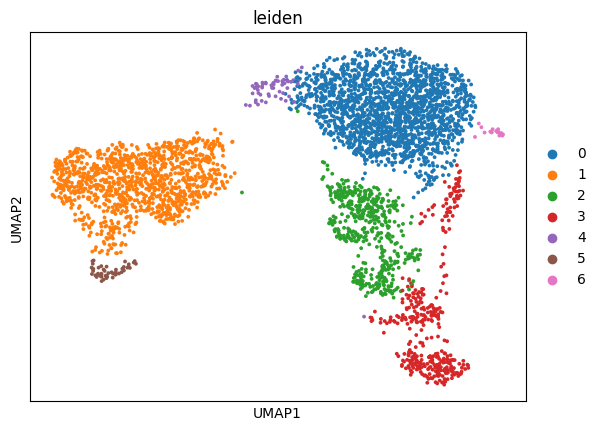

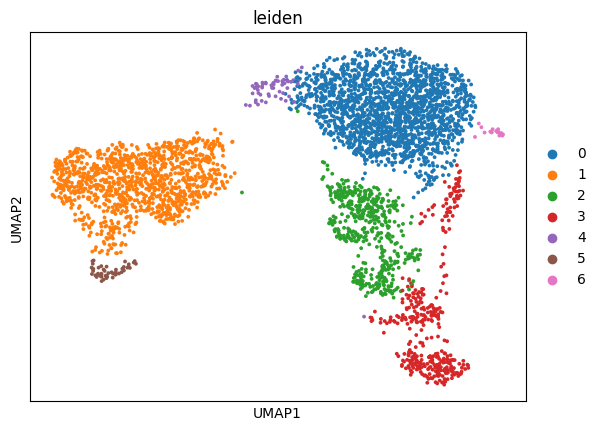

In [51]:
sc.tl.umap(adata_gene)
sc.pl.umap(adata_gene, color=['leiden'])
sc.pl.umap(adata_gene, color=['leiden'])

In [52]:
antigen_colors

{'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}

In [ ]:
# color_palette = [antigen_colors[cat] for cat in bind_list]
# sc.pl.umap(
#     adata_gene, 
#     color=['antigen'], 
#     palette=antigen_colors
# )

In [55]:
normalized_mutual_info_score(
    adata_gene.obs['leiden'].astype('int').values,
    adata_gene.obs['peptide'].astype('category').cat.codes.values
)

0.34487548120447975

In [56]:
from sklearn.metrics.cluster import adjusted_rand_score
ari_score = adjusted_rand_score(adata_gene.obs['leiden'].astype('int').values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.3615014321532906


In [57]:
adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.3615014321532906


In [22]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(donor_4_peptides)]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([20,25, 30,35 ,40, 45]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
  0%|          | 0/6 [00:00<?, ?it/s]2026-03-03 10:44:36.648751: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F A

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.4329804313009634, PCs: 20
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.4934439366062406, PCs: 20
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5171674205868239, PCs: 20
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5092049580819263, PCs: 20
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5026423787003226, PCs: 20
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5953863492162835, PCs: 20
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.43153453100427636, PCs: 20
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.44790938475603603, PCs: 20
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.41316939350629445, PCs: 20
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.47128616713456767, PCs: 20
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.4612051286390285, PCs: 20
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4448899248616722, PCs: 20
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.39563787417714547, PCs: 20
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.43

 17%|█▋        | 1/6 [01:17<06:27, 77.60s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.3388710456840916, PCs: 20
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.43636050832449813, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.44462404814358036, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.521596161994503, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5466855135977329, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5821572405984392, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5940776955690112, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.43184482456649326, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.4459086106998542, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.5085981296194756, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.44403022289206817, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.4468840839279001, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4475693458021522, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.4028

 33%|███▎      | 2/6 [02:22<04:41, 70.37s/it]

...

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.35634028822561337, PCs: 35
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.42929796559132083, PCs: 40
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.5156555616996457, PCs: 40
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.539824150170261, PCs: 40
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5478692959586823, PCs: 40
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5474538162981935, PCs: 40
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5474538162981935, PCs: 40
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.43103173634574693, PCs: 40
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.43366660052345074, PCs: 40
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.457932936660676, PCs: 40
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.4537892459161706, PCs: 40
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.44756770371391114, PCs: 40
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4647649660507641, PCs: 40
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.3973

 83%|████████▎ | 5/6 [05:46<01:08, 68.98s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.34395745308341824, PCs: 40
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.45564931072327886, PCs: 45
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.5473133219934053, PCs: 45
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.5083405044434922, PCs: 45
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.5082507158225334, PCs: 45
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.5842063337700932, PCs: 45
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.5021916358063863, PCs: 45
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.4535949441524969, PCs: 45
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.5151685696529613, PCs: 45
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.49617602944897277, PCs: 45
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.4751808821348533, PCs: 45
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.46627915516652285, PCs: 45
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.47904231925160906, PCs: 45
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.40

100%|██████████| 6/6 [06:51<00:00, 68.56s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.3655154520180327, PCs: 45
Best NMI Score: 0.5953863492162835 at Resolution: 0.3, N_neighbors: 30, PCs: 20


In [23]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
GGCAATTCAAGTAATG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134662,5858.0,3.767749,2371,0.041482,124095,1
TCCCGATGTCAGTGGA-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134679,3509.0,3.545183,1499,0.062696,124108,1
AACGTTGCATCGATTG-5,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134696,3913.0,3.592510,2047,0.061334,124124,2
AAACCTGGTCCATCCT-5,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134704,1169.0,3.067815,606,0.131737,124132,2
TAGCCGGAGGACAGAA-3,TRAV29DV5,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-6,TRAC,TRBC1,CAGTGNQFYF,CASSFEQGNSPLHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134719,6245.0,3.795532,2016,0.062450,124145,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,2
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,0
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,2


In [24]:
adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.24013649350744626

NMI Score: 0.5953863492162835


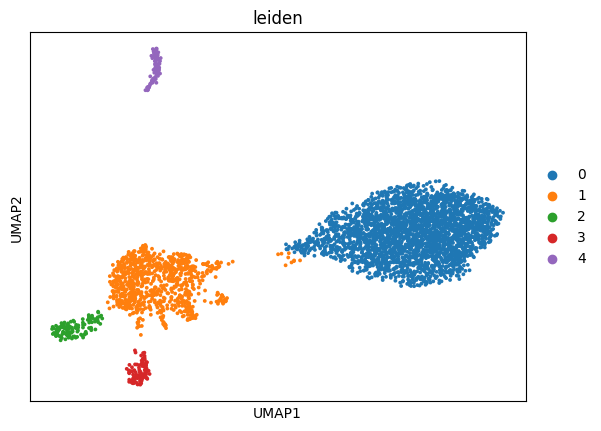

In [25]:
sc.pp.neighbors(adata_emb, n_neighbors = best_n_neighbors, n_pcs=best_npcs)
sc.tl.leiden(adata_emb, resolution=best_resolution)
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")
sc.tl.umap(adata_emb)
sc.pl.umap(adata_emb, color=['leiden'])

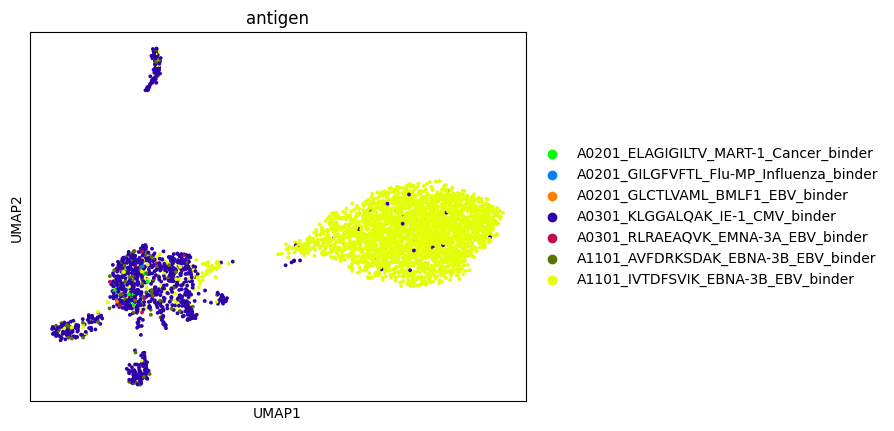

In [26]:
antigen_colors = {'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}
sc.pl.umap(
    adata_emb, 
    color=['antigen'], 
    palette=antigen_colors
)

In [27]:
# adata_emb.obs['antigen_color'] = [antigen_colors[x] for x in adata_emb.obs['antigen'].values]
# adata_emb.obs

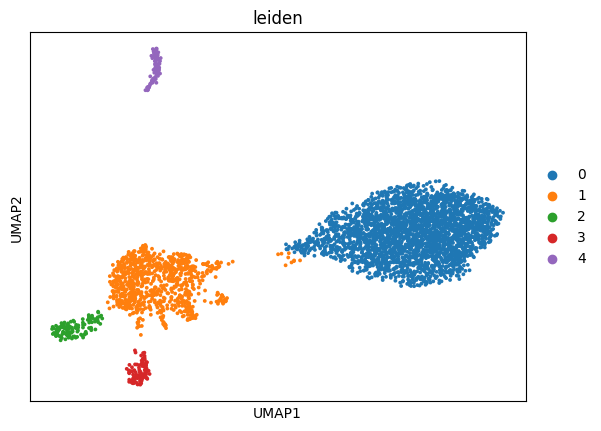

In [28]:
sc.pl.umap(adata_emb, color=['leiden'])

In [29]:
adata_emb.obs['antigen'].value_counts()

antigen
A1101_IVTDFSVIK_EBNA-3B_EBV_binder         2924
A0301_KLGGALQAK_IE-1_CMV_binder             919
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder         127
A0201_ELAGIGILTV_MART-1_Cancer_binder        15
A0301_RLRAEAQVK_EMNA-3A_EBV_binder           15
A0201_GLCTLVAML_BMLF1_EBV_binder              1
A0201_GILGFVFTL_Flu-MP_Influenza_binder       1
Name: count, dtype: int64

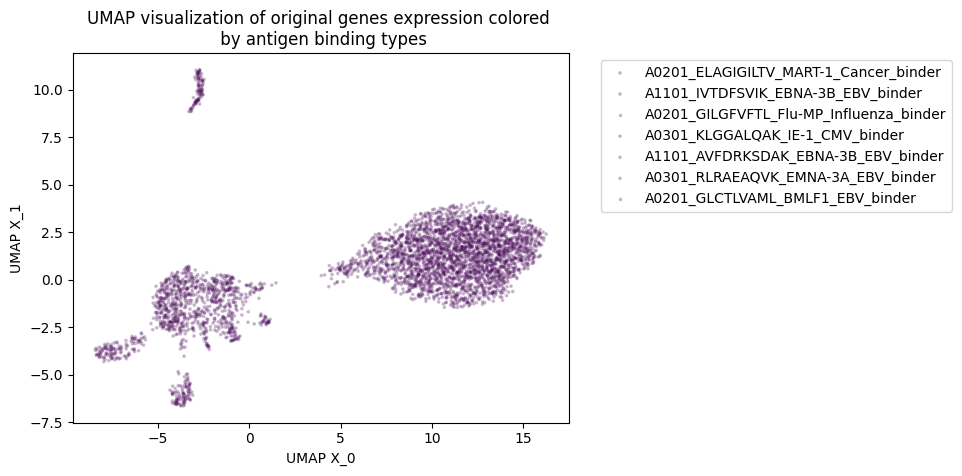

In [30]:
uniq = list(set(adata_emb.obs['antigen'].values))
alpha = 0.2

for i in range(len(uniq)):
    indx = adata_emb.obs['antigen'] == uniq[i]
    plt.scatter(adata_emb.obsm['X_umap'][list(indx),0], adata_emb.obsm['X_umap'][list(indx),1], s=3, c=adata_emb.obs['antigen'].astype('category').cat.codes.values[indx],label=uniq[i], alpha=alpha)

plt.xlabel('UMAP X_0')
plt.ylabel('UMAP X_1')
plt.title('UMAP visualization of original genes expression colored \n by antigen binding types')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.show()

In [31]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
GGCAATTCAAGTAATG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134662,5858.0,3.767749,2371,0.041482,124095,0
TCCCGATGTCAGTGGA-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134679,3509.0,3.545183,1499,0.062696,124108,0
AACGTTGCATCGATTG-5,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134696,3913.0,3.592510,2047,0.061334,124124,0
AAACCTGGTCCATCCT-5,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,134704,1169.0,3.067815,606,0.131737,124132,0
TAGCCGGAGGACAGAA-3,TRAV29DV5,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-6,TRAC,TRBC1,CAGTGNQFYF,CASSFEQGNSPLHF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,134719,6245.0,3.795532,2016,0.062450,124145,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,0
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,0
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,0


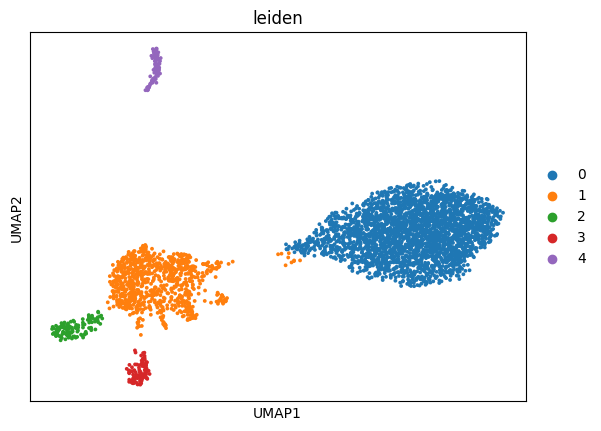

In [32]:
sc.pl.umap(adata_emb, color=['leiden'])

In [33]:
# sc.pl.umap(adata_emb, color=['IR_VDJ_1_junction_aa'])

In [34]:
# data_10X_dat[['cdr3b','Peptide_sequence']].groupby('cdr3b').value_counts().sort_values(ascending=False)

In [35]:
# data_10X_dat[data_10X_dat.cdr3b == "CASSLGFPNQPQHF"]        

In [36]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "TTDPSFLGRY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts().sort_values(ascending=False)        

In [37]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "LTDEMIAQY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts()        

In [38]:
from sklearn.metrics.cluster import normalized_mutual_info_score

In [39]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.5953863492162835


In [40]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.40972992104836475


In [41]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRA'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.4370763498081012


In [42]:
ari_score = adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.8202522248741819


In [43]:
adjusted_rand_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.7876171182320196

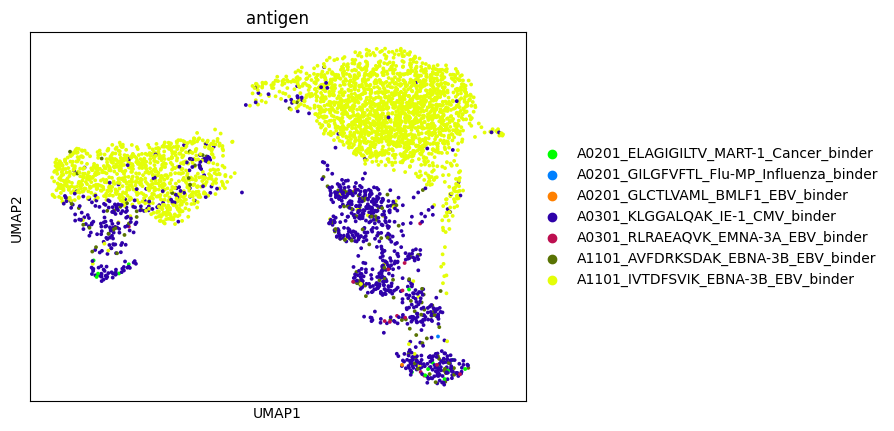

In [54]:
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)